In [1]:
# =============================================================================
# 셀 1: 환경 / 경로 / 유틸
# =============================================================================
# 목적: QP2 프로젝트 SSOT 경로 로드 + 공용 유틸 함수 정의
# 산출물: 없음 (환경 세팅만)
# 주의: 02_H.ipynb 셀 1과 동일 구조
# =============================================================================

import os, warnings
from pathlib import Path
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ── SSOT 경로 ──
load_dotenv(Path("C:/QP2/.env"))
QP2_ROOT   = Path(os.getenv("QP2_ROOT", "C:/QP2"))
DATA_DIR   = QP2_ROOT / "data"
RAW_DIR    = DATA_DIR / "raw"
INTERIM_DIR= DATA_DIR / "interim"
META_DIR   = DATA_DIR / "meta"

# ── W-21 전용 파라미터 ──
LOOKBACK_M      = 1          # 리더 급등 판정 룩백 (월)
SURGE_SIGMA     = 1.5        # 리더 급등 기준: 섹터 평균 + N*σ
TOP_N           = 30         # 최종 매수 종목 수
COST_BP         = 20         # 편도 거래비용 (bp)
REGIME_COL      = "regime"


# ── 공용 유틸 ──
def winsorize(s, lower=0.01, upper=0.99):
    """시리즈 양 끝 윈저라이즈"""
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lo, hi)

def zscore_by_date(df, col):
    """날짜별 횡단면 z-score"""
    g = df.groupby("date")[col]
    return (df[col] - g.transform("mean")) / g.transform("std")

def calc_perf(cum_ret):
    """누적수익률 시리즈 → CAGR, Sharpe, MaxDD 딕셔너리"""
    total = cum_ret.iloc[-1] / cum_ret.iloc[0]
    n_years = len(cum_ret) / 12
    cagr = total ** (1 / n_years) - 1 if n_years > 0 else 0
    monthly_ret = cum_ret.pct_change().dropna()
    sharpe = monthly_ret.mean() / monthly_ret.std() * np.sqrt(12) if monthly_ret.std() > 0 else 0
    drawdown = cum_ret / cum_ret.cummax() - 1
    maxdd = drawdown.min()
    return {"CAGR": cagr, "Sharpe": sharpe, "MaxDD": maxdd}

def calc_tstat(port_ret, bm_ret):
    """포트폴리오 vs 벤치마크 월간 수익률 차이의 t-stat"""
    diff = port_ret - bm_ret
    n = len(diff)
    if n < 2 or diff.std() == 0:
        return 0.0
    return diff.mean() / diff.std() * np.sqrt(n)

VALID_REGIMES = ["Bull"]

print(f"QP2_ROOT: {QP2_ROOT}")
print(f"W-21 파라미터: LOOKBACK={LOOKBACK_M}M, SURGE={SURGE_SIGMA}σ, TOP_N={TOP_N}")
print("셀 1 완료")

QP2_ROOT: C:\QP2
W-21 파라미터: LOOKBACK=1M, SURGE=1.5σ, TOP_N=30
셀 1 완료


In [2]:
# =============================================================================
# 셀 2: 데이터 로드 + 섹터 매핑 + 리더 정의
# =============================================================================
# 목적: 주가/수익률/레짐/섹터 로드, 섹터별 시총 Top1을 리더로 정의
# 산출물: px_m, ret_1m, regime_m, sector_map, mktcap_m, leader_map
# 주의: 리더 = 해당 월 기준 섹터 내 시총 1위 (매월 갱신)
# =============================================================================

# ── 주가 / 수익률 ──
px_wide = pd.read_parquet(INTERIM_DIR / "yahoo_adjclose_wide.parquet")
px_wide.index = pd.to_datetime(px_wide.index)

# 월말 리샘플
px_m = px_wide.resample("ME").last()
ret_1m = px_m.pct_change()

# 공통 종목 (NaN 과다 제거)
valid_tickers = ret_1m.columns[ret_1m.notna().sum() > len(ret_1m) * 0.5]
ret_1m = ret_1m[valid_tickers]
px_m = px_m[valid_tickers]

# EW 벤치마크
ew_ret = ret_1m.mean(axis=1)

# ── 레짐 ──
regime_all = pd.read_parquet(INTERIM_DIR / "regime_v4.parquet")
regime_all.index = pd.to_datetime(regime_all.index)
regime_m = regime_all[REGIME_COL].resample("ME").last().ffill()

# ── 섹터 매핑 ──
universe = pd.read_parquet(META_DIR / "sp500_universe.parquet")
sector_map = universe.set_index("ticker_yahoo")["GICS Sector"].to_dict()

# ret_1m에 있는 종목만 필터
sector_map = {t: s for t, s in sector_map.items() if t in ret_1m.columns}
print(f"섹터 매핑 종목 수: {len(sector_map)}")
print(f"섹터 수: {len(set(sector_map.values()))}")

# ── 시가총액 ──
mktcap_m = pd.read_parquet(INTERIM_DIR / "mktcap_monthly.parquet")
mktcap_m.index = pd.to_datetime(mktcap_m.index)

# ── 섹터별 리더 정의 (매월, 시총 1위) ──
# 리더는 매월 바뀔 수 있음 (ex: 2020년 AAPL → 2024년 NVDA 등)
sectors = set(sector_map.values())
ticker_to_sector = pd.Series(sector_map)
ticker_to_sector_s = ticker_to_sector  # 이후 셀 호환용

leader_records = []
for date in mktcap_m.index:
    row = mktcap_m.loc[date].dropna()
    for sect in sectors:
        sect_tickers = ticker_to_sector[ticker_to_sector == sect].index
        sect_tickers = sect_tickers.intersection(row.index)
        if len(sect_tickers) == 0:
            continue
        sect_caps = row[sect_tickers]
        leader = sect_caps.idxmax()
        leader_records.append({
            "date": date,
            "sector": sect,
            "leader": leader,
            "leader_mktcap": sect_caps[leader]
        })

leader_map = pd.DataFrame(leader_records)
print(f"\n리더 매핑: {len(leader_map)} rows, "
      f"기간 {leader_map['date'].min().strftime('%Y-%m')} ~ "
      f"{leader_map['date'].max().strftime('%Y-%m')}")

# 리더 분포 확인 (최근 날짜 기준)
latest = leader_map[leader_map["date"] == leader_map["date"].max()]
print(f"\n최근 리더 ({latest['date'].iloc[0].strftime('%Y-%m')}):")
for _, r in latest.sort_values("sector").iterrows():
    print(f"  {r['sector']:30s} → {r['leader']}")


# ── 레짐 매핑 함수 ──
def get_regime_for_date(date):
    idx = regime_m.index[regime_m.index <= date]
    if len(idx) == 0:
        return "UNKNOWN"
    return regime_m.loc[idx[-1]]

print("\n셀 2 완료")

섹터 매핑 종목 수: 277
섹터 수: 11

리더 매핑: 2255 rows, 기간 2009-01 ~ 2026-01

최근 리더 (2026-01):
  Communication Services         → DIS
  Consumer Discretionary         → HD
  Consumer Staples               → WMT
  Energy                         → XOM
  Financials                     → JPM
  Health Care                    → LLY
  Industrials                    → CAT
  Information Technology         → AAPL
  Materials                      → LIN
  Real Estate                    → WELL
  Utilities                      → NEE

셀 2 완료


In [3]:
# =============================================================================
# 셀 3-r: 일간 기반 리더 급등 감지 + 후발 시그널 생성
# =============================================================================
# 목적: 일간 수익률 기준 리더 급등 이벤트 감지, 후발주 시그널 생성
# 산출물: w21_daily_signal (date, ticker, sector, w21_raw, w21_z)
# 주의:
#   - 리더 급등 = 당일 리더 수익률 > 섹터평균 + SURGE_SIGMA * 섹터std(20일 롤링)
#   - 후발주 = 같은 섹터, 당일 수익률 < 섹터 중앙값
#   - 리더: 월별 시총 Top1 (월초 기준, 매일 바꾸진 않음)
# =============================================================================

from tqdm import tqdm

# ── 일간 수익률 ──
ret_1d = px_wide.pct_change()
common_tickers = ret_1d.columns.intersection(ticker_to_sector_s.index)
ret_1d = ret_1d[common_tickers]

# ── 리더 매핑을 일간으로 확장 (월초 기준 고정) ──
# leader_map은 월말 date 기준 → 해당 월 전체에 적용
leader_daily = {}
for _, row in leader_map.iterrows():
    # 해당 월의 모든 거래일에 리더 매핑
    ym = row["date"].strftime("%Y-%m")
    leader_daily[(ym, row["sector"])] = row["leader"]

# ── 섹터별 20일 롤링 σ 계산 ──
# 섹터 평균 일간 수익률의 롤링 std
sectors_list = sorted(set(ticker_to_sector_s.values))

# 섹터별 일간 평균 수익률
sect_ret_daily = {}
for sect in sectors_list:
    tks = ticker_to_sector_s[ticker_to_sector_s == sect].index
    tks = tks.intersection(ret_1d.columns)
    if len(tks) > 0:
        sect_ret_daily[sect] = ret_1d[tks].mean(axis=1)

sect_ret_df = pd.DataFrame(sect_ret_daily)
sect_roll_std = sect_ret_df.rolling(20, min_periods=10).std()

# ── 시그널 생성 ──
SURGE_SIGMA_D = 2.0  # 일간은 좀 더 높은 기준

# 분석 기간 제한 (2013-06 이후, 데이터 안정 구간)
start_date = pd.Timestamp("2013-06-19")
trading_days = ret_1d.index[ret_1d.index >= start_date]

records = []

for date in tqdm(trading_days, desc="W-21 daily signal"):
    ym = date.strftime("%Y-%m")
    day_ret = ret_1d.loc[date].dropna()
    
    if date not in sect_roll_std.index:
        continue
    
    for sect in sectors_list:
        # 리더 찾기
        key = (ym, sect)
        if key not in leader_daily:
            continue
        leader = leader_daily[key]
        
        # 섹터 종목
        sect_tickers = ticker_to_sector_s[ticker_to_sector_s == sect].index
        sect_tickers = sect_tickers.intersection(day_ret.index)
        if len(sect_tickers) < 5 or leader not in day_ret.index:
            continue
        
        sect_ret = day_ret[sect_tickers]
        leader_ret = sect_ret[leader]
        sect_mean = sect_ret.mean()
        
        # 롤링 σ
        roll_s = sect_roll_std.loc[date, sect] if sect in sect_roll_std.columns else None
        if roll_s is None or pd.isna(roll_s) or roll_s == 0:
            continue
        
        # ── 리더 급등 판정 ──
        if leader_ret <= sect_mean + SURGE_SIGMA_D * roll_s:
            continue
        
        # ── 후발주: 당일 섹터 중앙값 미만 ──
        sect_median = sect_ret.median()
        non_leader = sect_ret.drop(leader, errors="ignore")
        laggards = non_leader[non_leader < sect_median]
        
        for ticker in laggards.index:
            gap = sect_median - sect_ret[ticker]
            records.append({
                "date": date,
                "ticker": ticker,
                "sector": sect,
                "leader": leader,
                "leader_ret": leader_ret,
                "ticker_ret": sect_ret[ticker],
                "w21_raw": gap
            })

w21_daily = pd.DataFrame(records)

if len(w21_daily) > 0:
    w21_daily["w21_z"] = zscore_by_date(w21_daily, "w21_raw")

print(f"\nW-21 일간 시그널 생성 완료")
print(f"  총 rows: {len(w21_daily):,}")
print(f"  기간: {w21_daily['date'].min().strftime('%Y-%m-%d')} ~ "
      f"{w21_daily['date'].max().strftime('%Y-%m-%d')}")
print(f"  이벤트 발생일 수: {w21_daily['date'].nunique():,}")
print(f"  전체 거래일 대비: {w21_daily['date'].nunique() / len(trading_days) * 100:.1f}%")
print(f"  고유 종목 수: {w21_daily['ticker'].nunique()}")
print(f"\n이벤트 빈도:")
events_per_day = w21_daily.groupby('date')['sector'].nunique()
print(f"  이벤트일 평균: {events_per_day.mean():.1f} 섹터/일")
picks_per_day = w21_daily.groupby('date').size()
print(f"  이벤트일 평균 후보 종목: {picks_per_day.mean():.1f}")

print("\n셀 3-r 완료")

W-21 daily signal: 100%|██████████| 3181/3181 [00:37<00:00, 83.87it/s]


W-21 일간 시그널 생성 완료
  총 rows: 13,688
  기간: 2013-07-19 ~ 2026-01-30
  이벤트 발생일 수: 804
  전체 거래일 대비: 25.3%
  고유 종목 수: 276

이벤트 빈도:
  이벤트일 평균: 1.2 섹터/일
  이벤트일 평균 후보 종목: 17.0

셀 3-r 완료


In [4]:
# =============================================================================
# 셀 5: H팩터 상관관계 분석 + 잔차 알파 테스트
# =============================================================================
# 목적: W-21 시그널에서 H팩터로 설명되는 부분을 제거하고,
#        잔차(순수 leader-laggard 효과)만으로 알파 유무 확인
# 산출물: W-21 raw vs H 상관, 잔차 백테스트 결과
# 주의:
#   - H = 섹터 3M 모멘텀 z-score (02_H.ipynb 동일 로직)
#   - 잔차 = W-21_z - β * H_z (횡단면 회귀 잔차)
# =============================================================================

# ── H 시그널 재생성 (3M 섹터 모멘텀 → 종목 레벨 z-score) ──
H_LOOKBACK = 3  # 02_H.ipynb 확정 파라미터

# 월간 섹터 EW 수익률
sect_ret_monthly = {}
for sect in sectors_list:
    tks = ticker_to_sector_s[ticker_to_sector_s == sect].index
    tks = tks.intersection(ret_1m.columns)
    if len(tks) > 0:
        sect_ret_monthly[sect] = ret_1m[tks].mean(axis=1)

sect_ret_m_df = pd.DataFrame(sect_ret_monthly)

# 3M 롤링 섹터 모멘텀
sect_mom_3m = sect_ret_m_df.rolling(H_LOOKBACK).sum()

# 섹터 모멘텀 → 횡단면 z-score (섹터 레벨)
def sect_zscore(row):
    m, s = row.mean(), row.std()
    return (row - m) / s if s > 0 else row * 0

sect_mom_z = sect_mom_3m.apply(sect_zscore, axis=1)

# 종목 레벨 H-score: 해당 종목의 섹터 z-score를 매핑
# 일간으로 확장 (월말 기준 → 해당 월 전체 적용)
h_monthly = {}
for date in sect_mom_z.index:
    if pd.isna(sect_mom_z.loc[date]).all():
        continue
    for ticker in ticker_to_sector_s.index:
        sect = ticker_to_sector_s[ticker]
        if sect in sect_mom_z.columns and not pd.isna(sect_mom_z.loc[date, sect]):
            h_monthly[(date, ticker)] = sect_mom_z.loc[date, sect]

h_score_monthly = pd.Series(h_monthly)
h_score_monthly.index = pd.MultiIndex.from_tuples(h_score_monthly.index, names=["date_m", "ticker"])
h_score_monthly = h_score_monthly.reset_index()
h_score_monthly.columns = ["date_m", "ticker", "h_z"]

# ── W-21 이벤트에 H-score 매칭 ──
# W-21 이벤트의 date → 해당 월말로 매핑해서 H-score 결합
w21_daily["date_m"] = w21_daily["date"].dt.to_period("M").dt.to_timestamp("M")

w21_h = w21_daily.merge(h_score_monthly, on=["date_m", "ticker"], how="left")

valid_both = w21_h.dropna(subset=["w21_z", "h_z"])
print(f"W-21 × H 매칭: {len(valid_both):,} / {len(w21_daily):,} rows")

# ── 상관관계 ──
corr = valid_both["w21_z"].corr(valid_both["h_z"])
print(f"\nW-21 vs H 신호 상관계수: {corr:.4f}")

# ── 횡단면 회귀로 잔차 추출 ──
# 날짜별 W-21_z = α + β*H_z + ε
# ε = W-21의 순수 leader-laggard 효과
from numpy.linalg import lstsq

residuals = []
dates_with_data = valid_both["date"].unique()

for date in dates_with_data:
    chunk = valid_both[valid_both["date"] == date]
    if len(chunk) < 5:
        continue
    
    y = chunk["w21_z"].values
    X = np.column_stack([np.ones(len(chunk)), chunk["h_z"].values])
    
    coef, _, _, _ = lstsq(X, y, rcond=None)
    resid = y - X @ coef
    
    for i, (_, row) in enumerate(chunk.iterrows()):
        residuals.append({
            "date": date,
            "ticker": row["ticker"],
            "sector": row["sector"],
            "w21_z": row["w21_z"],
            "h_z": row["h_z"],
            "w21_resid": resid[i]
        })

w21_resid = pd.DataFrame(residuals)
print(f"잔차 추출 완료: {len(w21_resid):,} rows")

# ── 잔차 기반 백테스트 (20d, Top20) vs Raw 비교 ──
def backtest_signal_col(signal_df, score_col, px_wide, hold_days=20, top_n=20, cost_bp=20):
    """범용 이벤트 백테스트 — score_col 기준 top_n 선정"""
    cost = cost_bp / 10000 * 2
    trade_records = []
    event_dates = sorted(signal_df["date"].unique())
    all_dates = px_wide.index.sort_values()
    
    for edate in event_dates:
        future = all_dates[all_dates > edate]
        if len(future) < hold_days + 1:
            continue
        entry_date = future[0]
        exit_date = future[hold_days]
        
        ev_sig = signal_df[signal_df["date"] == edate].nlargest(top_n, score_col)
        picks = [t for t in ev_sig["ticker"].values if t in px_wide.columns]
        
        if len(picks) < 3:
            continue
        
        entry_p = px_wide.loc[entry_date, picks]
        exit_p = px_wide.loc[exit_date, picks]
        valid = entry_p.notna() & exit_p.notna() & (entry_p > 0)
        
        if valid.sum() < 3:
            continue
        
        rets = exit_p[valid] / entry_p[valid] - 1
        trade_records.append({
            "entry": entry_date,
            "exit": exit_date,
            "n_stocks": int(valid.sum()),
            "net_ret": rets.mean() - cost
        })
    
    return pd.DataFrame(trade_records)

# Raw W-21
bt_raw = backtest_signal_col(w21_resid, "w21_z", px_wide, 20, 20)
# 잔차 기반
bt_resid = backtest_signal_col(w21_resid, "w21_resid", px_wide, 20, 20)

def summarize(bt, label):
    if bt.empty:
        return {}
    n = len(bt)
    avg = bt["net_ret"].mean()
    t = avg / bt["net_ret"].std() * np.sqrt(n) if bt["net_ret"].std() > 0 else 0
    hit = (bt["net_ret"] > 0).mean()
    return {
        "Version": label,
        "Trades": n,
        "Avg_Ret%": round(avg * 100, 3),
        "Hit%": round(hit * 100, 1),
        "t_stat": round(t, 3)
    }

comp = pd.DataFrame([
    summarize(bt_raw, "W-21 Raw"),
    summarize(bt_resid, "W-21 Residual (H 제거)")
])

print("\n" + "="*70)
print("W-21 vs W-21 잔차 (H 영향 제거) 비교")
print("="*70)
print(comp.to_string(index=False))

# ── 포트폴리오 겹침률 ──
overlap_records = []
for date in dates_with_data:
    raw_top = w21_resid[w21_resid["date"] == date].nlargest(20, "w21_z")["ticker"].values
    res_top = w21_resid[w21_resid["date"] == date].nlargest(20, "w21_resid")["ticker"].values
    if len(raw_top) > 0 and len(res_top) > 0:
        overlap = len(set(raw_top) & set(res_top)) / max(len(raw_top), len(res_top))
        overlap_records.append(overlap)

avg_overlap = np.mean(overlap_records) if overlap_records else 0
print(f"\nRaw vs Residual 포트폴리오 평균 겹침률: {avg_overlap*100:.1f}%")

print("\n셀 5 완료")

W-21 × H 매칭: 13,688 / 13,688 rows

W-21 vs H 신호 상관계수: -0.0044
잔차 추출 완료: 13,403 rows

W-21 vs W-21 잔차 (H 영향 제거) 비교
             Version  Trades  Avg_Ret%  Hit%  t_stat
            W-21 Raw     704     0.590  57.0   3.125
W-21 Residual (H 제거)     704     0.568  56.8   3.009

Raw vs Residual 포트폴리오 평균 겹침률: 98.5%

셀 5 완료


In [5]:
# =============================================================================
# 셀 15: Gross 수익률 비교 (비용 제거)
# =============================================================================
# 목적: 거래비용 제거하고 순수 tier별 초과수익 확인
#        기존 결과가 비용 왜곡인지, 진짜 무알파인지 판별
# 산출물: 보유기간 × tier gross 초과수익
# =============================================================================

from tqdm import tqdm

def backtest_gross(px_wide, mktcap_m, ticker_to_sector_s,
                    sect_roll_std, sect_mom_z, sectors_list,
                    hold_days=20, surge_sigma=2.0,
                    valid_regimes=None, h_min_z=0.0):
    all_dates = px_wide.index.sort_values()
    ret_1d_local = px_wide.pct_change()
    common = ret_1d_local.columns.intersection(ticker_to_sector_s.index)
    ret_1d_local = ret_1d_local[common]
    
    start_date = pd.Timestamp("2013-06-19")
    trading_days = ret_1d_local.index[ret_1d_local.index >= start_date]
    
    trades = []
    
    for date in trading_days:
        if valid_regimes:
            reg = get_regime_for_date(date)
            if reg not in valid_regimes:
                continue
        
        day_ret = ret_1d_local.loc[date].dropna()
        if date not in sect_roll_std.index:
            continue
        
        m_end = date.to_period("M").to_timestamp("M")
        if m_end not in mktcap_m.index:
            continue
        m_cap = mktcap_m.loc[m_end].dropna()
        
        if m_end not in sect_mom_z.index:
            continue
        h_row = sect_mom_z.loc[m_end]
        
        for sect in sectors_list:
            if sect not in h_row.index or pd.isna(h_row[sect]):
                continue
            if h_row[sect] < h_min_z:
                continue
            
            sect_tickers = ticker_to_sector_s[ticker_to_sector_s == sect].index
            sect_tickers = sect_tickers.intersection(day_ret.index).intersection(m_cap.index)
            if len(sect_tickers) < 8:
                continue
            
            sect_ret = day_ret[sect_tickers]
            sect_caps = m_cap[sect_tickers]
            leader = sect_caps.idxmax()
            
            if leader not in sect_ret.index:
                continue
            
            leader_ret_today = sect_ret[leader]
            sect_mean = sect_ret.mean()
            roll_s = sect_roll_std.loc[date, sect] if sect in sect_roll_std.columns else None
            if roll_s is None or pd.isna(roll_s) or roll_s == 0:
                continue
            
            if leader_ret_today <= sect_mean + surge_sigma * roll_s:
                continue
            
            future = all_dates[all_dates > date]
            if len(future) < hold_days + 2:
                continue
            entry_date = future[1]
            exit_date = future[1 + hold_days]
            
            # 시총 tier
            non_leader_caps = sect_caps.drop(leader, errors="ignore")
            q25 = non_leader_caps.quantile(0.25)
            q75 = non_leader_caps.quantile(0.75)
            
            top_tier = non_leader_caps[non_leader_caps >= q75].index.tolist()
            middle = non_leader_caps[(non_leader_caps >= q25) & (non_leader_caps < q75)].index.tolist()
            laggard = non_leader_caps[non_leader_caps < q25].index.tolist()
            
            def tier_ret_gross(picks):
                picks = [t for t in picks if t in px_wide.columns]
                if len(picks) < 1:
                    return np.nan
                ep = px_wide.loc[entry_date, picks]
                xp = px_wide.loc[exit_date, picks]
                v = ep.notna() & xp.notna() & (ep > 0)
                if v.sum() < 1:
                    return np.nan
                return (xp[v] / ep[v] - 1).mean()  # NO COST
            
            # 섹터 EW (리더 포함, NO COST)
            sect_all = [t for t in sect_tickers if t in px_wide.columns]
            sect_ep = px_wide.loc[entry_date, sect_all]
            sect_xp = px_wide.loc[exit_date, sect_all]
            sv = sect_ep.notna() & sect_xp.notna() & (sect_ep > 0)
            sect_ew = (sect_xp[sv] / sect_ep[sv] - 1).mean() if sv.sum() > 3 else np.nan
            
            trades.append({
                "date": date,
                "sector": sect,
                "leader_ret": tier_ret_gross([leader]),
                "top_ret": tier_ret_gross(top_tier),
                "mid_ret": tier_ret_gross(middle),
                "lag_ret": tier_ret_gross(laggard),
                "sect_ew": sect_ew
            })
    
    return pd.DataFrame(trades)


# ── 보유기간 민감도 (gross) ──
hold_range = [5, 10, 15, 20, 30, 40, 60]
all_results = []

for hold in tqdm(hold_range, desc="Gross 민감도"):
    bt = backtest_gross(
        px_wide, mktcap_m, ticker_to_sector_s,
        sect_roll_std, sect_mom_z, sectors_list,
        hold_days=hold, surge_sigma=2.0,
        valid_regimes=VALID_REGIMES, h_min_z=0.0
    )
    
    if bt.empty:
        continue
    
    bt = bt.dropna(subset=["mid_ret", "sect_ew"])
    
    for col, label in [("leader_ret", "Leader"),
                       ("top_ret", "Top(Q4)"),
                       ("mid_ret", "Mid(Q2-Q3)"),
                       ("lag_ret", "Lag(Q1)")]:
        excess = (bt[col] - bt["sect_ew"]).dropna()
        n = len(excess)
        if n < 5:
            continue
        avg = excess.mean()
        t = avg / excess.std() * np.sqrt(n) if excess.std() > 0 else 0
        hit = (excess > 0).mean()
        
        all_results.append({
            "Hold": f"{hold}d",
            "Tier": label,
            "N": n,
            "Excess%": round(avg * 100, 3),
            "Hit%": round(hit * 100, 1),
            "t_stat": round(t, 3)
        })

res_df = pd.DataFrame(all_results)

print("=" * 80)
print("GROSS 수익률 — 시총Tier vs SectorEW (비용 없음)")
print("H유효 섹터, Bull, 다음날 진입")
print("=" * 80)

for tier in ["Leader", "Top(Q4)", "Mid(Q2-Q3)", "Lag(Q1)"]:
    sub = res_df[res_df["Tier"] == tier]
    print(f"\n--- {tier} ---")
    print(sub[["Hold", "N", "Excess%", "Hit%", "t_stat"]].to_string(index=False))

print("\n셀 15 완료")

Gross 민감도: 100%|██████████| 7/7 [03:23<00:00, 29.06s/it]

GROSS 수익률 — 시총Tier vs SectorEW (비용 없음)
H유효 섹터, Bull, 다음날 진입

--- Leader ---
Hold   N  Excess%  Hit%  t_stat
  5d 394   -0.114  47.2  -0.684
 10d 394   -0.287  47.5  -1.281
 15d 394   -0.406  44.7  -1.469
 20d 393   -0.735  44.3  -2.323
 30d 389   -1.164  46.0  -2.792
 40d 387   -1.164  46.5  -2.281
 60d 381   -1.419  45.7  -2.174

--- Top(Q4) ---
Hold   N  Excess%  Hit%  t_stat
  5d 394    0.143  57.4   2.832
 10d 394    0.163  55.6   2.461
 15d 394    0.142  53.6   1.686
 20d 393    0.134  53.7   1.413
 30d 389    0.093  53.0   0.795
 40d 387   -0.051  49.6  -0.362
 60d 381    0.081  52.5   0.459

--- Mid(Q2-Q3) ---
Hold   N  Excess%  Hit%  t_stat
  5d 394   -0.063  46.7  -1.991
 10d 394   -0.008  49.2  -0.183
 15d 394    0.032  54.3   0.628
 20d 393    0.039  53.4   0.675
 30d 389    0.020  47.8   0.270
 40d 387    0.040  49.6   0.457
 60d 381    0.060  49.9   0.538

--- Lag(Q1) ---
Hold   N  Excess%  Hit%  t_stat
  5d 394   -0.027  48.0  -0.476
 10d 394   -0.132  47.2  -1.661
 15d 3

초단기 Gross: 100%|██████████| 8/8 [03:49<00:00, 28.72s/it]


GROSS 초단기 — 시총Tier vs SectorEW
H유효 섹터, Bull, 다음날 진입

--- Leader ---
Hold   N  Excess%  Hit%  t_stat
  1d 394    0.011  50.0   0.157
  2d 394   -0.064  47.5  -0.669
  3d 394   -0.080  49.0  -0.646
  5d 394   -0.114  47.2  -0.684
  7d 394   -0.118  46.4  -0.618
 10d 394   -0.287  47.5  -1.281
 15d 394   -0.406  44.7  -1.469
 20d 393   -0.735  44.3  -2.323

--- Top(Q4) ---
Hold   N  Excess%  Hit%  t_stat
  1d 394    0.010  53.0   0.479
  2d 394    0.052  53.0   1.708
  3d 394    0.104  58.6   2.709
  5d 394    0.143  57.4   2.832
  7d 394    0.179  57.9   3.208
 10d 394    0.163  55.6   2.461
 15d 394    0.142  53.6   1.686
 20d 393    0.134  53.7   1.413

--- Mid(Q2-Q3) ---
Hold   N  Excess%  Hit%  t_stat
  1d 394   -0.009  50.5  -0.663
  2d 394   -0.034  46.4  -1.772
  3d 394   -0.057  47.0  -2.333
  5d 394   -0.063  46.7  -1.991
  7d 394   -0.052  48.0  -1.443
 10d 394   -0.008  49.2  -0.183
 15d 394    0.032  54.3   0.628
 20d 393    0.039  53.4   0.675

--- Lag(Q1) ---
Hold   N  Exce

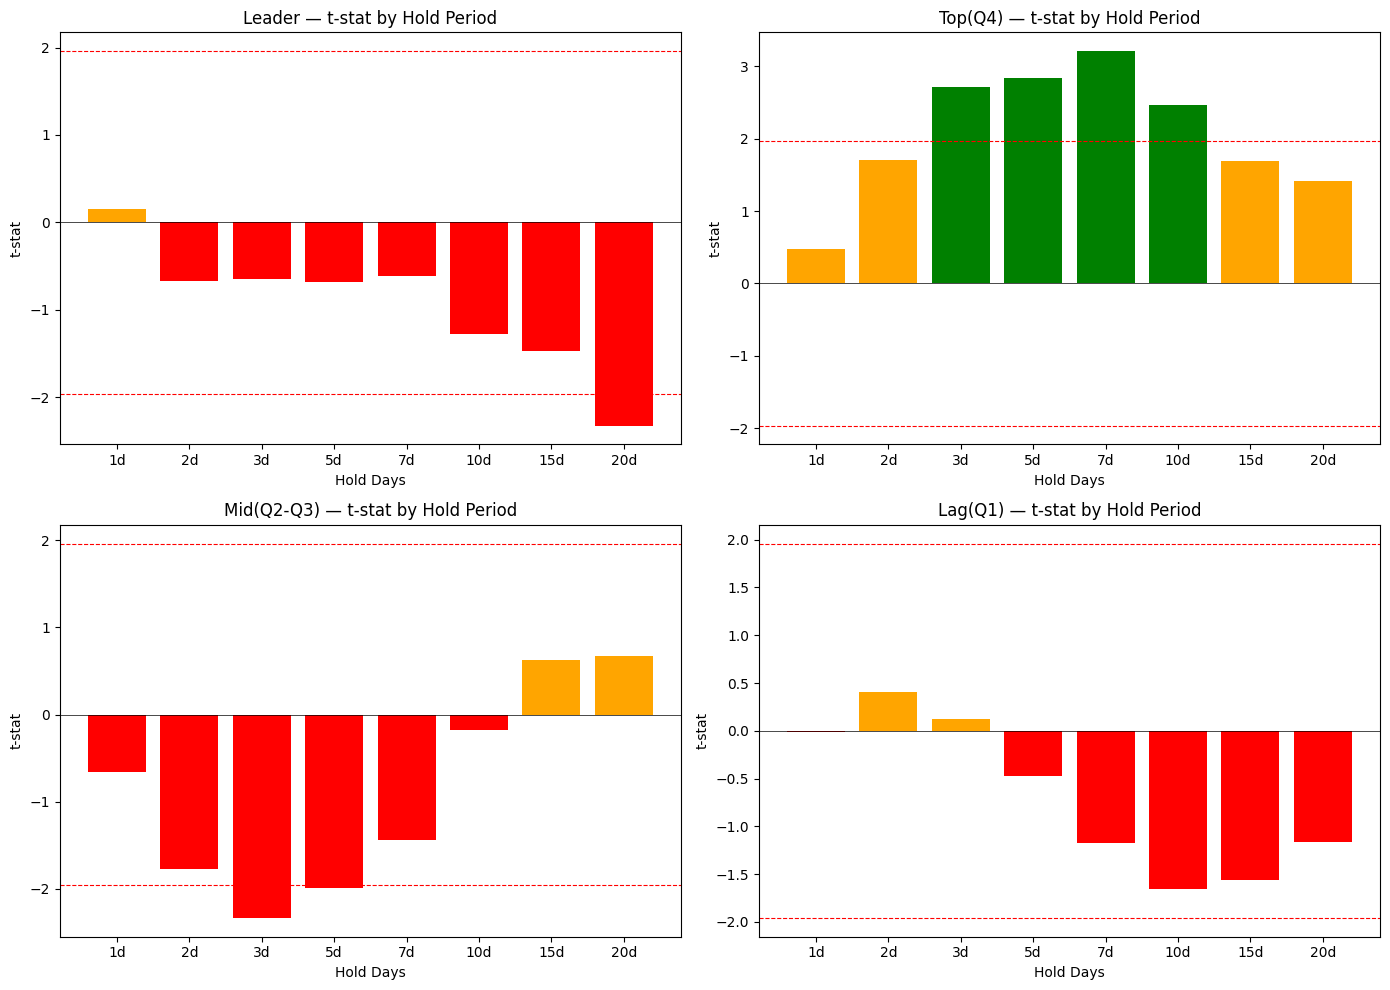


셀 16 완료


In [6]:
# =============================================================================
# 셀 16: 초단기 보유 추가 (1d, 3d) — Gross
# =============================================================================
# 목적: 1d, 3d 보유에서 tier별 초과수익 확인
#        스필오버가 초단기에 발생하는지 검증
# 산출물: 1d~20d 전체 비교표
# =============================================================================

from tqdm import tqdm

hold_range_short = [1, 2, 3, 5, 7, 10, 15, 20]
all_results = []

for hold in tqdm(hold_range_short, desc="초단기 Gross"):
    bt = backtest_gross(
        px_wide, mktcap_m, ticker_to_sector_s,
        sect_roll_std, sect_mom_z, sectors_list,
        hold_days=hold, surge_sigma=2.0,
        valid_regimes=VALID_REGIMES, h_min_z=0.0
    )
    
    if bt.empty:
        continue
    
    bt = bt.dropna(subset=["mid_ret", "sect_ew"])
    
    for col, label in [("leader_ret", "Leader"),
                       ("top_ret", "Top(Q4)"),
                       ("mid_ret", "Mid(Q2-Q3)"),
                       ("lag_ret", "Lag(Q1)")]:
        excess = (bt[col] - bt["sect_ew"]).dropna()
        n = len(excess)
        if n < 5:
            continue
        avg = excess.mean()
        t = avg / excess.std() * np.sqrt(n) if excess.std() > 0 else 0
        hit = (excess > 0).mean()
        
        all_results.append({
            "Hold": hold,
            "Tier": label,
            "N": n,
            "Excess%": round(avg * 100, 3),
            "Hit%": round(hit * 100, 1),
            "t_stat": round(t, 3)
        })

res_df = pd.DataFrame(all_results)

print("=" * 80)
print("GROSS 초단기 — 시총Tier vs SectorEW")
print("H유효 섹터, Bull, 다음날 진입")
print("=" * 80)

for tier in ["Leader", "Top(Q4)", "Mid(Q2-Q3)", "Lag(Q1)"]:
    sub = res_df[res_df["Tier"] == tier].copy()
    print(f"\n--- {tier} ---")
    sub["Hold"] = sub["Hold"].astype(str) + "d"
    print(sub[["Hold", "N", "Excess%", "Hit%", "t_stat"]].to_string(index=False))

# ── 전 tier 시각화 ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
tier_list = ["Leader", "Top(Q4)", "Mid(Q2-Q3)", "Lag(Q1)"]

for ax, tier in zip(axes.flat, tier_list):
    sub = res_df[res_df["Tier"] == tier].copy()
    if sub.empty:
        continue
    sub["t_stat"] = sub["t_stat"].astype(float)
    colors = ["green" if t > 1.96 else "orange" if t > 0 else "red"
              for t in sub["t_stat"]]
    ax.bar(range(len(sub)), sub["t_stat"].values, color=colors,
           tick_label=[f"{h}d" for h in sub["Hold"].values])
    ax.axhline(1.96, color="red", linewidth=0.8, linestyle="--")
    ax.axhline(-1.96, color="red", linewidth=0.8, linestyle="--")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(f"{tier} — t-stat by Hold Period")
    ax.set_xlabel("Hold Days")
    ax.set_ylabel("t-stat")

plt.tight_layout()
plt.show()

print("\n셀 16 완료")

σ 민감도:   0%|          | 0/9 [00:00<?, ?it/s]

σ 민감도: 100%|██████████| 9/9 [04:50<00:00, 32.25s/it]


σ 민감도 — Top(Q4) × 7d hold, Gross, H유효+Bull
   σ  Events  Event_days  Excess%  Hit%  t_stat
0.50    3146        1768    0.017  52.2   0.859
0.75    2125        1389    0.025  52.3   1.027
1.00    1476        1084    0.026  52.0   0.905
1.25    1045         839    0.049  52.9   1.417
1.50     740         629    0.067  53.8   1.609
1.75     544         486    0.126  56.6   2.559
2.00     394         366    0.179  57.9   3.208
2.50     246         235    0.233  58.9   3.212
3.00     149         144    0.357  64.4   3.631


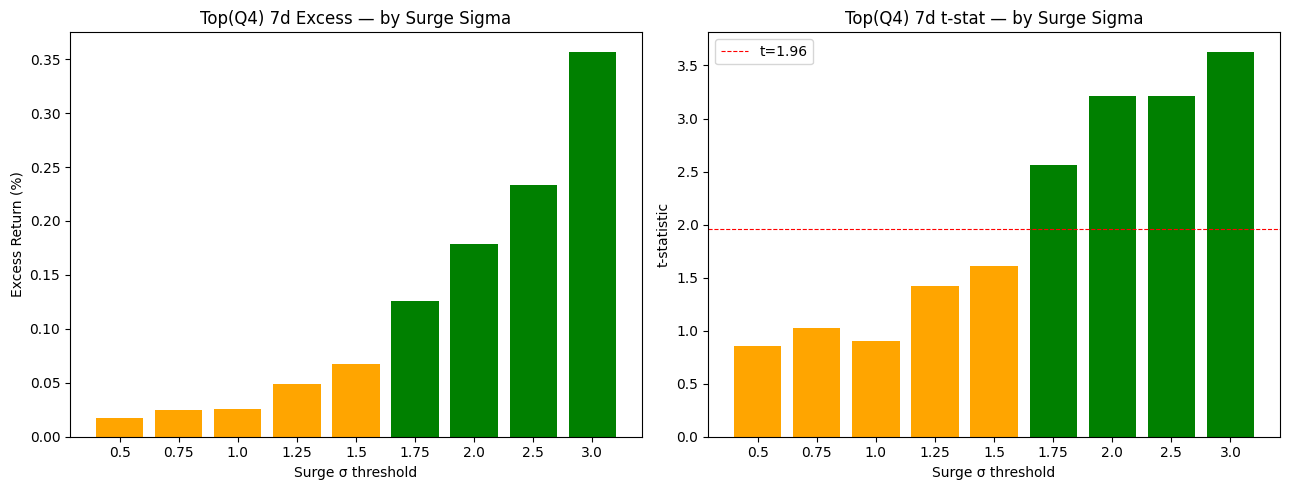


셀 17 완료


In [7]:
# =============================================================================
# 셀 17: σ 민감도 — Top(Q4) × 7d 고정
# =============================================================================
# 목적: σ를 낮춰 이벤트 수 늘렸을 때 Top Q4 7d 알파가 유지되는지
# 산출물: σ별 성과 비교표
# 주의: σ 낮추면 이벤트 늘지만 시그널 품질 떨어질 수 있음
# =============================================================================

from tqdm import tqdm

def backtest_gross_single(px_wide, mktcap_m, ticker_to_sector_s,
                           sect_roll_std, sect_mom_z, sectors_list,
                           hold_days=7, surge_sigma=2.0,
                           valid_regimes=None, h_min_z=0.0):
    """Top Q4만 리턴하는 경량 버전"""
    all_dates = px_wide.index.sort_values()
    ret_1d_local = px_wide.pct_change()
    common = ret_1d_local.columns.intersection(ticker_to_sector_s.index)
    ret_1d_local = ret_1d_local[common]
    
    start_date = pd.Timestamp("2013-06-19")
    trading_days = ret_1d_local.index[ret_1d_local.index >= start_date]
    
    trades = []
    
    for date in trading_days:
        if valid_regimes:
            reg = get_regime_for_date(date)
            if reg not in valid_regimes:
                continue
        
        day_ret = ret_1d_local.loc[date].dropna()
        if date not in sect_roll_std.index:
            continue
        
        m_end = date.to_period("M").to_timestamp("M")
        if m_end not in mktcap_m.index:
            continue
        m_cap = mktcap_m.loc[m_end].dropna()
        
        if m_end not in sect_mom_z.index:
            continue
        h_row = sect_mom_z.loc[m_end]
        
        for sect in sectors_list:
            if sect not in h_row.index or pd.isna(h_row[sect]):
                continue
            if h_row[sect] < h_min_z:
                continue
            
            sect_tickers = ticker_to_sector_s[ticker_to_sector_s == sect].index
            sect_tickers = sect_tickers.intersection(day_ret.index).intersection(m_cap.index)
            if len(sect_tickers) < 8:
                continue
            
            sect_ret = day_ret[sect_tickers]
            sect_caps = m_cap[sect_tickers]
            leader = sect_caps.idxmax()
            
            if leader not in sect_ret.index:
                continue
            
            leader_ret_today = sect_ret[leader]
            sect_mean = sect_ret.mean()
            roll_s = sect_roll_std.loc[date, sect] if sect in sect_roll_std.columns else None
            if roll_s is None or pd.isna(roll_s) or roll_s == 0:
                continue
            
            if leader_ret_today <= sect_mean + surge_sigma * roll_s:
                continue
            
            future = all_dates[all_dates > date]
            if len(future) < hold_days + 2:
                continue
            entry_date = future[1]
            exit_date = future[1 + hold_days]
            
            # Top Q4만
            non_leader_caps = sect_caps.drop(leader, errors="ignore")
            q75 = non_leader_caps.quantile(0.75)
            top_tier = non_leader_caps[non_leader_caps >= q75].index.tolist()
            top_tier = [t for t in top_tier if t in px_wide.columns]
            
            if len(top_tier) < 1:
                continue
            
            ep = px_wide.loc[entry_date, top_tier]
            xp = px_wide.loc[exit_date, top_tier]
            v = ep.notna() & xp.notna() & (ep > 0)
            if v.sum() < 1:
                continue
            top_ret = (xp[v] / ep[v] - 1).mean()
            
            # 섹터 EW
            sect_all = [t for t in sect_tickers if t in px_wide.columns]
            sect_ep = px_wide.loc[entry_date, sect_all]
            sect_xp = px_wide.loc[exit_date, sect_all]
            sv = sect_ep.notna() & sect_xp.notna() & (sect_ep > 0)
            sect_ew = (sect_xp[sv] / sect_ep[sv] - 1).mean() if sv.sum() > 3 else np.nan
            
            if pd.isna(sect_ew):
                continue
            
            trades.append({
                "date": date,
                "sector": sect,
                "top_ret": top_ret,
                "sect_ew": sect_ew,
                "excess": top_ret - sect_ew
            })
    
    return pd.DataFrame(trades)


# ── σ 범위 ──
sigma_range = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]

results = []

for sig in tqdm(sigma_range, desc="σ 민감도"):
    bt = backtest_gross_single(
        px_wide, mktcap_m, ticker_to_sector_s,
        sect_roll_std, sect_mom_z, sectors_list,
        hold_days=7, surge_sigma=sig,
        valid_regimes=VALID_REGIMES, h_min_z=0.0
    )
    
    if bt.empty:
        continue
    
    n = len(bt)
    avg = bt["excess"].mean()
    std = bt["excess"].std()
    t = avg / std * np.sqrt(n) if std > 0 else 0
    hit = (bt["excess"] > 0).mean()
    events_days = bt["date"].nunique()
    
    results.append({
        "σ": sig,
        "Events": n,
        "Event_days": events_days,
        "Excess%": round(avg * 100, 3),
        "Hit%": round(hit * 100, 1),
        "t_stat": round(t, 3)
    })

sig_df = pd.DataFrame(results)

print("=" * 80)
print("σ 민감도 — Top(Q4) × 7d hold, Gross, H유효+Bull")
print("=" * 80)
print(sig_df.to_string(index=False))

# ── 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ["green" if t > 1.96 else "orange" if t > 0 else "red"
          for t in sig_df["t_stat"]]

axes[0].bar(range(len(sig_df)), sig_df["Excess%"].values, color=colors,
            tick_label=[str(s) for s in sig_df["σ"].values])
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_xlabel("Surge σ threshold")
axes[0].set_ylabel("Excess Return (%)")
axes[0].set_title("Top(Q4) 7d Excess — by Surge Sigma")

axes[1].bar(range(len(sig_df)), sig_df["t_stat"].values, color=colors,
            tick_label=[str(s) for s in sig_df["σ"].values])
axes[1].axhline(1.96, color="red", linewidth=0.8, linestyle="--", label="t=1.96")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_xlabel("Surge σ threshold")
axes[1].set_ylabel("t-statistic")
axes[1].set_title("Top(Q4) 7d t-stat — by Surge Sigma")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n셀 17 완료")

σ sweep (최적화): 100%|██████████| 7/7 [04:12<00:00, 36.04s/it]


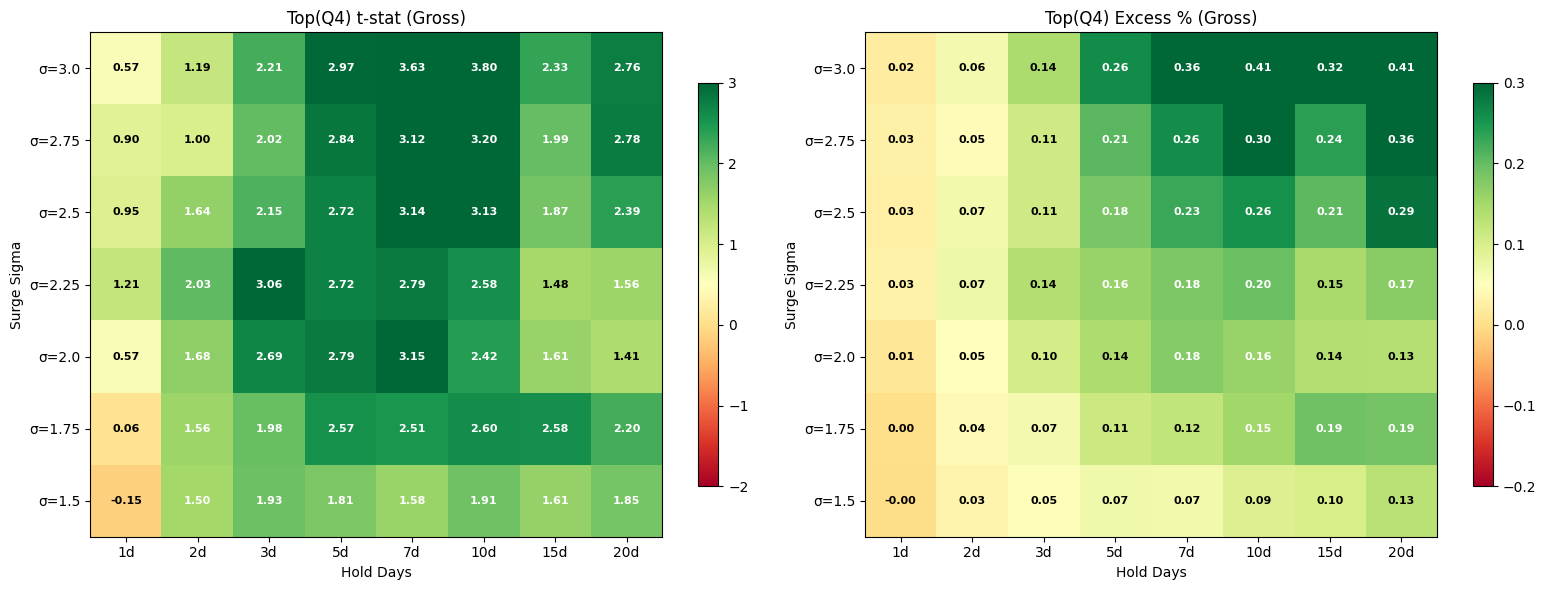


2D Sweep — Top(Q4) Gross, H유효+Bull

t-stat:
Hold     1      2      3      5      7      10     15     20
σ                                                           
3.00  0.570  1.187  2.205  2.966  3.631  3.799  2.332  2.758
2.75  0.902  1.001  2.022  2.841  3.125  3.202  1.993  2.779
2.50  0.948  1.644  2.152  2.724  3.142  3.131  1.874  2.388
2.25  1.213  2.032  3.063  2.724  2.795  2.583  1.480  1.565
2.00  0.572  1.675  2.687  2.786  3.151  2.421  1.611  1.413
1.75  0.064  1.559  1.980  2.569  2.511  2.601  2.577  2.203
1.50 -0.149  1.503  1.926  1.812  1.580  1.913  1.615  1.854

Excess%:
Hold     1      2      3      5      7      10     15     20
σ                                                           
3.00  0.021  0.064  0.142  0.262  0.357  0.410  0.316  0.407
2.75  0.028  0.046  0.110  0.208  0.259  0.301  0.238  0.358
2.50  0.025  0.067  0.110  0.183  0.229  0.257  0.206  0.287
2.25  0.029  0.072  0.137  0.160  0.181  0.195  0.146  0.172
2.00  0.012  0.051  0.103  0.1

In [8]:
# =============================================================================
# 셀 18: σ × Hold 2D 민감도 — Top(Q4) Gross (최적화)
# =============================================================================
# 목적: σ별로 이벤트 1번만 감지, 보유기간은 수익률만 재계산
# 산출물: 히트맵 (Excess%, t-stat)
# 최적화: σ당 1회 루프, hold는 벡터 계산
# =============================================================================

from tqdm import tqdm

sigma_range = [1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
hold_range = [1, 2, 3, 5, 7, 10, 15, 20]
max_hold = max(hold_range)

all_dates = px_wide.index.sort_values()
ret_1d_local = px_wide.pct_change()
common = ret_1d_local.columns.intersection(ticker_to_sector_s.index)
ret_1d_local = ret_1d_local[common]
start_date = pd.Timestamp("2013-06-19")
trading_days = ret_1d_local.index[ret_1d_local.index >= start_date]

results = []

for sig in tqdm(sigma_range, desc="σ sweep (최적화)"):
    # ── 이벤트 감지 + 모든 hold 수익률 한번에 ──
    events = []
    
    for date in trading_days:
        reg = get_regime_for_date(date)
        if reg not in VALID_REGIMES:
            continue
        
        if date not in sect_roll_std.index:
            continue
        day_ret = ret_1d_local.loc[date].dropna()
        
        m_end = date.to_period("M").to_timestamp("M")
        if m_end not in mktcap_m.index:
            continue
        m_cap = mktcap_m.loc[m_end].dropna()
        
        if m_end not in sect_mom_z.index:
            continue
        h_row = sect_mom_z.loc[m_end]
        
        for sect in sectors_list:
            if sect not in h_row.index or pd.isna(h_row[sect]) or h_row[sect] < 0.0:
                continue
            
            sect_tickers = ticker_to_sector_s[ticker_to_sector_s == sect].index
            sect_tickers = sect_tickers.intersection(day_ret.index).intersection(m_cap.index)
            if len(sect_tickers) < 8:
                continue
            
            sect_ret = day_ret[sect_tickers]
            sect_caps = m_cap[sect_tickers]
            leader = sect_caps.idxmax()
            
            if leader not in sect_ret.index:
                continue
            
            leader_ret_today = sect_ret[leader]
            sect_mean = sect_ret.mean()
            roll_s = sect_roll_std.loc[date, sect] if sect in sect_roll_std.columns else None
            if roll_s is None or pd.isna(roll_s) or roll_s == 0:
                continue
            
            if leader_ret_today <= sect_mean + sig * roll_s:
                continue
            
            # 이벤트 감지됨 — 모든 hold 수익률 계산
            future = all_dates[all_dates > date]
            if len(future) < max_hold + 2:
                continue
            entry_date = future[1]
            
            # Top Q4
            non_leader_caps = sect_caps.drop(leader, errors="ignore")
            q75 = non_leader_caps.quantile(0.75)
            top_tier = non_leader_caps[non_leader_caps >= q75].index.tolist()
            top_tier = [t for t in top_tier if t in px_wide.columns]
            if len(top_tier) < 1:
                continue
            
            ep_top = px_wide.loc[entry_date, top_tier]
            
            # 섹터 EW
            sect_all = [t for t in sect_tickers if t in px_wide.columns]
            ep_sect = px_wide.loc[entry_date, sect_all]
            
            evt = {"date": date, "sector": sect}
            
            for hold in hold_range:
                exit_date = future[1 + hold] if len(future) > 1 + hold else None
                if exit_date is None:
                    continue
                
                # Top Q4 수익률
                xp_top = px_wide.loc[exit_date, top_tier]
                v = ep_top.notna() & xp_top.notna() & (ep_top > 0)
                top_ret = (xp_top[v] / ep_top[v] - 1).mean() if v.sum() > 0 else np.nan
                
                # Sect EW
                xp_sect = px_wide.loc[exit_date, sect_all]
                sv = ep_sect.notna() & xp_sect.notna() & (ep_sect > 0)
                sect_ew = (xp_sect[sv] / ep_sect[sv] - 1).mean() if sv.sum() > 3 else np.nan
                
                evt[f"excess_{hold}d"] = top_ret - sect_ew if not (pd.isna(top_ret) or pd.isna(sect_ew)) else np.nan
            
            events.append(evt)
    
    if not events:
        continue
    
    evt_df = pd.DataFrame(events)
    
    for hold in hold_range:
        col = f"excess_{hold}d"
        if col not in evt_df.columns:
            continue
        excess = evt_df[col].dropna()
        n = len(excess)
        if n < 10:
            continue
        avg = excess.mean()
        std = excess.std()
        t = avg / std * np.sqrt(n) if std > 0 else 0
        hit = (excess > 0).mean()
        
        results.append({
            "σ": sig,
            "Hold": hold,
            "N": n,
            "Excess%": round(avg * 100, 3),
            "Hit%": round(hit * 100, 1),
            "t_stat": round(t, 3)
        })

res_df = pd.DataFrame(results)

# ── 히트맵 ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (metric, title, cmap) in enumerate([
    ("t_stat", "Top(Q4) t-stat (Gross)", "RdYlGn"),
    ("Excess%", "Top(Q4) Excess % (Gross)", "RdYlGn")
]):
    pivot = res_df.pivot(index="σ", columns="Hold", values=metric)
    pivot = pivot.sort_index(ascending=False)
    
    vmin = -2 if metric == "t_stat" else -0.2
    vmax = 3 if metric == "t_stat" else 0.3
    
    im = axes[i].imshow(pivot.values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    
    axes[i].set_xticks(range(len(pivot.columns)))
    axes[i].set_xticklabels([f"{c}d" for c in pivot.columns])
    axes[i].set_yticks(range(len(pivot.index)))
    axes[i].set_yticklabels([f"σ={s}" for s in pivot.index])
    axes[i].set_xlabel("Hold Days")
    axes[i].set_ylabel("Surge Sigma")
    axes[i].set_title(title)
    
    for r in range(len(pivot.index)):
        for c in range(len(pivot.columns)):
            val = pivot.values[r, c]
            if not np.isnan(val):
                color = "white" if abs(val) > (1.5 if metric == "t_stat" else 0.15) else "black"
                axes[i].text(c, r, f"{val:.2f}", ha="center", va="center",
                           fontsize=8, color=color, fontweight="bold")
    
    plt.colorbar(im, ax=axes[i], shrink=0.8)

plt.tight_layout()
plt.show()

# ── 숫자 ──
print("\n" + "=" * 80)
print("2D Sweep — Top(Q4) Gross, H유효+Bull")
print("=" * 80)
print("\nt-stat:")
print(res_df.pivot(index="σ", columns="Hold", values="t_stat")
      .sort_index(ascending=False).to_string())
print("\nExcess%:")
print(res_df.pivot(index="σ", columns="Hold", values="Excess%")
      .sort_index(ascending=False).to_string())
print("\nN:")
print(res_df.pivot(index="σ", columns="Hold", values="N")
      .sort_index(ascending=False).to_string())

print("\n셀 18 완료")

레짐별: 100%|██████████| 4/4 [01:06<00:00, 16.58s/it]

레짐별 분해 — Top(Q4) × σ=2.5 × 7d hold, Gross
 Regime   N  Excess%  Hit%  t_stat
   Bull 246    0.233  58.9   3.212
   Bear  23   -0.311  30.4  -1.114
Neutral  16   -0.106  56.2  -0.325
    ALL 285    0.170  56.5   2.452


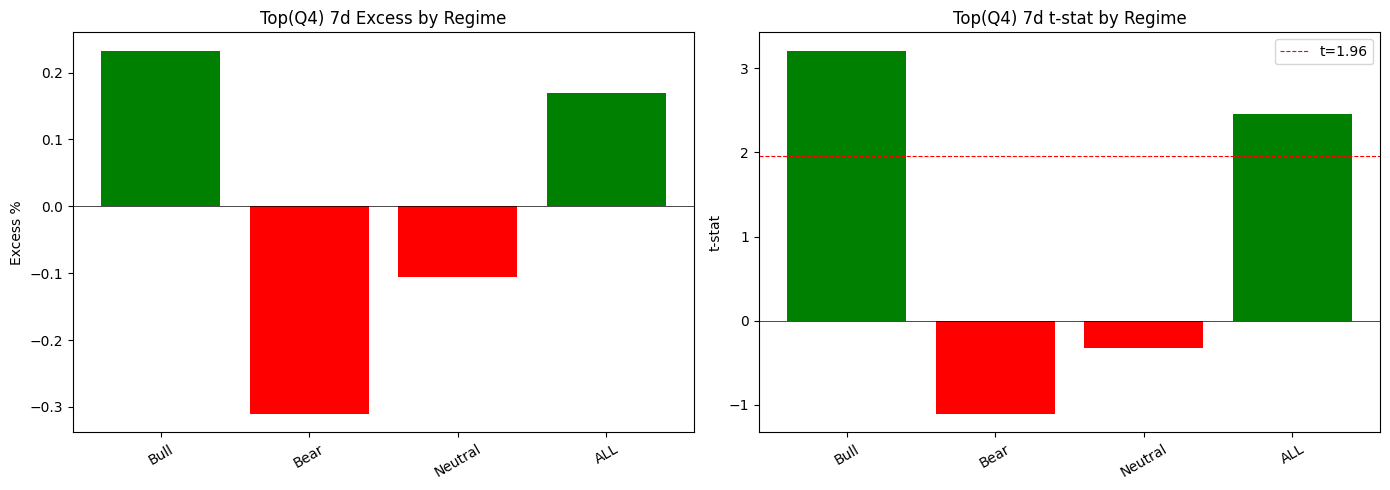


셀 19 완료


In [9]:
# =============================================================================
# 셀 19: σ=2.5 × 7d — 레짐별 분해
# =============================================================================
# 목적: Top(Q4) 7d 알파가 레짐 의존적인지 확인
# 산출물: 레짐별 Excess%, t-stat
# =============================================================================

# 셀 18에서 만든 backtest_gross_single 재활용, 레짐 필터만 바꿈
from tqdm import tqdm

all_regimes = ["Bull", "Bear", "Neutral"]

results = []

for reg in tqdm(all_regimes + ["ALL"], desc="레짐별"):
    valid = None if reg == "ALL" else [reg]
    
    bt = backtest_gross_single(
        px_wide, mktcap_m, ticker_to_sector_s,
        sect_roll_std, sect_mom_z, sectors_list,
        hold_days=7, surge_sigma=2.5,
        valid_regimes=valid, h_min_z=0.0
    )
    
    if bt.empty or len(bt) < 5:
        results.append({"Regime": reg, "N": 0, "Excess%": np.nan,
                        "Hit%": np.nan, "t_stat": np.nan})
        continue
    
    n = len(bt)
    avg = bt["excess"].mean()
    std = bt["excess"].std()
    t = avg / std * np.sqrt(n) if std > 0 else 0
    hit = (bt["excess"] > 0).mean()
    
    results.append({
        "Regime": reg,
        "N": n,
        "Excess%": round(avg * 100, 3),
        "Hit%": round(hit * 100, 1),
        "t_stat": round(t, 3)
    })

reg_df = pd.DataFrame(results)

print("=" * 80)
print("레짐별 분해 — Top(Q4) × σ=2.5 × 7d hold, Gross")
print("=" * 80)
print(reg_df.to_string(index=False))

# ── 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["green" if t > 1.96 else "orange" if t > 0 else "red"
          for t in reg_df["t_stat"]]

axes[0].bar(range(len(reg_df)), reg_df["Excess%"].values, color=colors,
            tick_label=reg_df["Regime"].values)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_ylabel("Excess %")
axes[0].set_title("Top(Q4) 7d Excess by Regime")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(range(len(reg_df)), reg_df["t_stat"].values, color=colors,
            tick_label=reg_df["Regime"].values)
axes[1].axhline(1.96, color="red", linewidth=0.8, linestyle="--", label="t=1.96")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_ylabel("t-stat")
axes[1].set_title("Top(Q4) 7d t-stat by Regime")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n셀 19 완료")

Lag Q1 레짐별: 100%|██████████| 4/4 [02:27<00:00, 36.98s/it]


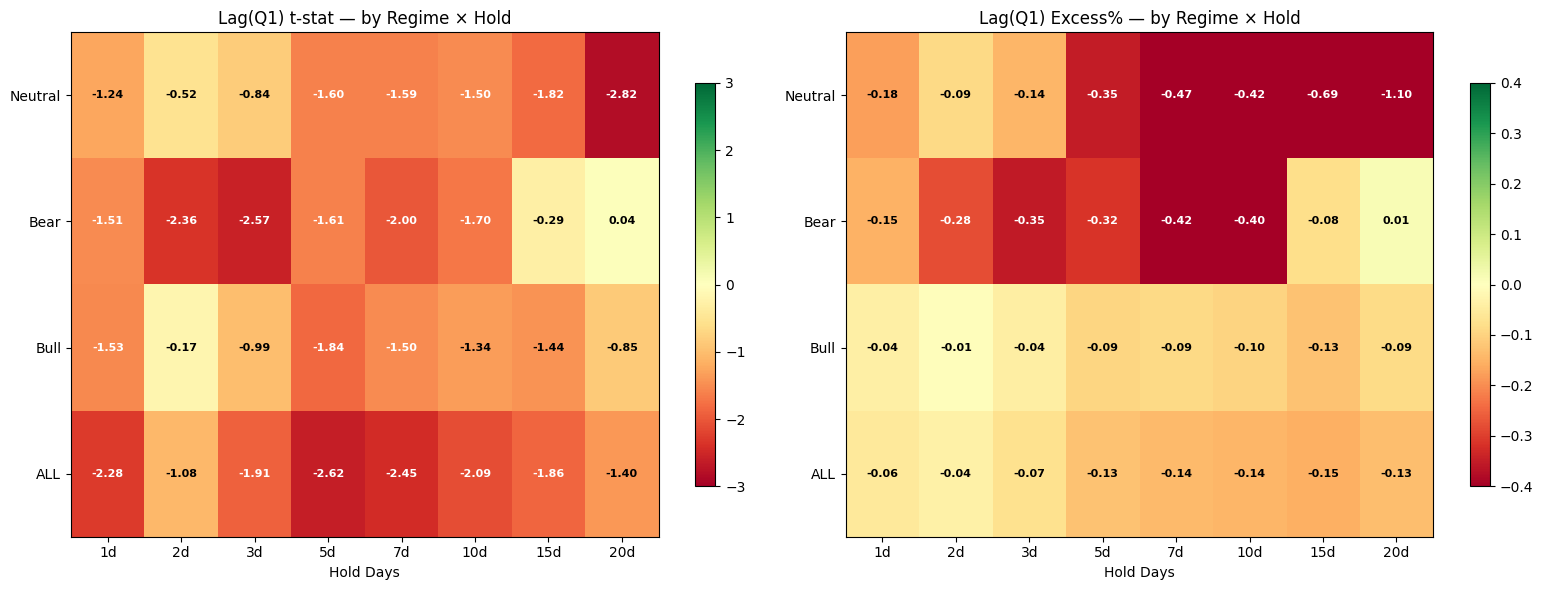


Lag(Q1) — 레짐 × 보유기간, σ=2.5, Gross, H필터 없음

t-stat:
Hold        1      2      3      5      7      10     15     20
Regime                                                         
Neutral -1.244 -0.517 -0.839 -1.605 -1.594 -1.504 -1.823 -2.818
Bear    -1.510 -2.358 -2.572 -1.606 -2.005 -1.704 -0.291  0.040
Bull    -1.527 -0.168 -0.990 -1.840 -1.502 -1.339 -1.440 -0.855
ALL     -2.283 -1.076 -1.911 -2.624 -2.450 -2.091 -1.863 -1.404

Excess%:
Hold        1      2      3      5      7      10     15     20
Regime                                                         
Neutral -0.176 -0.089 -0.144 -0.353 -0.472 -0.419 -0.689 -1.098
Bear    -0.151 -0.281 -0.355 -0.315 -0.416 -0.402 -0.081  0.013
Bull    -0.038 -0.006 -0.042 -0.094 -0.090 -0.100 -0.128 -0.086
ALL     -0.055 -0.035 -0.075 -0.128 -0.140 -0.144 -0.154 -0.132

N:
Hold      1    2    3    5    7    10   15   20
Regime                                         
Neutral   27   27   27   27   27   27   27   27
Bear      45   45   45

In [10]:
# =============================================================================
# 셀 22: Lag(Q1) 레짐별 분해 — σ=2.5 × 보유기간 sweep
# =============================================================================
# 목적: Lag tier가 섹터EW 대비 언더퍼폼하는 레짐/보유기간 탐색
# 산출물: 레짐 × 보유기간 Excess%, t-stat
# =============================================================================
# ── 선행 변수 (셀 2~3-r 의존) ──
all_dates = px_wide.index.sort_values()
ret_1d_local = px_wide.pct_change()
common = ret_1d_local.columns.intersection(ticker_to_sector_s.index)
ret_1d_local = ret_1d_local[common]
start_date = pd.Timestamp("2013-06-19")
trading_days = ret_1d_local.index[ret_1d_local.index >= start_date]

from tqdm import tqdm

all_regimes = ["Bull", "Bear", "Neutral"]
hold_range = [1, 2, 3, 5, 7, 10, 15, 20]
max_hold = max(hold_range)
SIG = 2.5

results = []

for reg in tqdm(all_regimes + ["ALL"], desc="Lag Q1 레짐별"):
    valid = None if reg == "ALL" else [reg]
    events = []
    
    for date in trading_days:
        if valid:
            r = get_regime_for_date(date)
            if r not in valid:
                continue
        
        if date not in sect_roll_std.index:
            continue
        day_ret = ret_1d_local.loc[date].dropna()
        
        m_end = date.to_period("M").to_timestamp("M")
        if m_end not in mktcap_m.index:
            continue
        m_cap = mktcap_m.loc[m_end].dropna()
        
        if m_end not in sect_mom_z.index:
            continue
        h_row = sect_mom_z.loc[m_end]
        
        for sect in sectors_list:
            if sect not in h_row.index or pd.isna(h_row[sect]):
                continue
            
            sect_tickers = ticker_to_sector_s[ticker_to_sector_s == sect].index
            sect_tickers = sect_tickers.intersection(day_ret.index).intersection(m_cap.index)
            if len(sect_tickers) < 8:
                continue
            
            sect_ret = day_ret[sect_tickers]
            sect_caps = m_cap[sect_tickers]
            leader = sect_caps.idxmax()
            
            if leader not in sect_ret.index:
                continue
            
            leader_ret_today = sect_ret[leader]
            sect_mean = sect_ret.mean()
            roll_s = sect_roll_std.loc[date, sect] if sect in sect_roll_std.columns else None
            if roll_s is None or pd.isna(roll_s) or roll_s == 0:
                continue
            
            if leader_ret_today <= sect_mean + SIG * roll_s:
                continue
            
            future = all_dates[all_dates > date]
            if len(future) < max_hold + 2:
                continue
            entry_date = future[1]
            
            # Lag Q1
            non_leader_caps = sect_caps.drop(leader, errors="ignore")
            q25 = non_leader_caps.quantile(0.25)
            lag_tier = non_leader_caps[non_leader_caps < q25].index.tolist()
            lag_tier = [t for t in lag_tier if t in px_wide.columns]
            if len(lag_tier) < 1:
                continue
            
            ep_lag = px_wide.loc[entry_date, lag_tier]
            sect_all = [t for t in sect_tickers if t in px_wide.columns]
            ep_sect = px_wide.loc[entry_date, sect_all]
            
            evt = {"date": date, "sector": sect}
            
            for hold in hold_range:
                if len(future) <= 1 + hold:
                    continue
                exit_date = future[1 + hold]
                
                xp_lag = px_wide.loc[exit_date, lag_tier]
                v = ep_lag.notna() & xp_lag.notna() & (ep_lag > 0)
                lag_ret = (xp_lag[v] / ep_lag[v] - 1).mean() if v.sum() > 0 else np.nan
                
                xp_sect = px_wide.loc[exit_date, sect_all]
                sv = ep_sect.notna() & xp_sect.notna() & (ep_sect > 0)
                sect_ew = (xp_sect[sv] / ep_sect[sv] - 1).mean() if sv.sum() > 3 else np.nan
                
                evt[f"excess_{hold}d"] = lag_ret - sect_ew if not (pd.isna(lag_ret) or pd.isna(sect_ew)) else np.nan
            
            events.append(evt)
    
    if not events:
        for hold in hold_range:
            results.append({"Regime": reg, "Hold": hold, "N": 0,
                           "Excess%": np.nan, "Hit%": np.nan, "t_stat": np.nan})
        continue
    
    evt_df = pd.DataFrame(events)
    
    for hold in hold_range:
        col = f"excess_{hold}d"
        if col not in evt_df.columns:
            continue
        excess = evt_df[col].dropna()
        n = len(excess)
        if n < 5:
            results.append({"Regime": reg, "Hold": hold, "N": n,
                           "Excess%": np.nan, "Hit%": np.nan, "t_stat": np.nan})
            continue
        avg = excess.mean()
        std = excess.std()
        t = avg / std * np.sqrt(n) if std > 0 else 0
        hit = (excess > 0).mean()
        
        results.append({
            "Regime": reg,
            "Hold": hold,
            "N": n,
            "Excess%": round(avg * 100, 3),
            "Hit%": round(hit * 100, 1),
            "t_stat": round(t, 3)
        })

res_df = pd.DataFrame(results)

# ── 히트맵 ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (metric, title) in enumerate([
    ("t_stat", "Lag(Q1) t-stat — by Regime × Hold"),
    ("Excess%", "Lag(Q1) Excess% — by Regime × Hold")
]):
    pivot = res_df.pivot(index="Regime", columns="Hold", values=metric)
    # 레짐 순서 고정
    order = ["Neutral", "Bear", "Bull", "ALL"]
    pivot = pivot.reindex([r for r in order if r in pivot.index])
    
    vmin = -3 if metric == "t_stat" else -0.4
    vmax = 3 if metric == "t_stat" else 0.4
    
    im = axes[i].imshow(pivot.values, aspect="auto", cmap="RdYlGn",
                         vmin=vmin, vmax=vmax)
    
    axes[i].set_xticks(range(len(pivot.columns)))
    axes[i].set_xticklabels([f"{c}d" for c in pivot.columns])
    axes[i].set_yticks(range(len(pivot.index)))
    axes[i].set_yticklabels(pivot.index)
    axes[i].set_xlabel("Hold Days")
    axes[i].set_title(title)
    
    for r in range(len(pivot.index)):
        for c in range(len(pivot.columns)):
            val = pivot.values[r, c]
            if not np.isnan(val):
                color = "white" if abs(val) > (1.5 if metric == "t_stat" else 0.2) else "black"
                axes[i].text(c, r, f"{val:.2f}", ha="center", va="center",
                           fontsize=8, color=color, fontweight="bold")
    
    plt.colorbar(im, ax=axes[i], shrink=0.8)

plt.tight_layout()
plt.show()

# ── 숫자 ──
print("\n" + "=" * 80)
print("Lag(Q1) — 레짐 × 보유기간, σ=2.5, Gross, H필터 없음")
print("=" * 80)
print("\nt-stat:")
pivot_t = res_df.pivot(index="Regime", columns="Hold", values="t_stat")
pivot_t = pivot_t.reindex([r for r in order if r in pivot_t.index])
print(pivot_t.to_string())
print("\nExcess%:")
pivot_e = res_df.pivot(index="Regime", columns="Hold", values="Excess%")
pivot_e = pivot_e.reindex([r for r in order if r in pivot_e.index])
print(pivot_e.to_string())
print("\nN:")
pivot_n = res_df.pivot(index="Regime", columns="Hold", values="N")
pivot_n = pivot_n.reindex([r for r in order if r in pivot_n.index])
print(pivot_n.to_string())

print("\n셀 22 완료")

In [11]:
# =============================================================================
# 05_T-1.ipynb — 최종 결론 (regime_v4 재검증)
# =============================================================================
"""
# T-1 Leader Spillover 최종 결론 — regime_v4 재검증

## 가설
  섹터 리더(시총 1위) 급등 시, 같은 섹터 Top Q4 종목이 spillover 수혜

---

## 레짐별 분해 (셀 19) — Top(Q4), σ=2.5, 7d hold

  Regime   N     Excess%   Hit%   t-stat
  Bull     246   +0.233    58.9   3.212   ✅
  Bear      23   -0.311    30.4  -1.114   ❌
  Neutral   16   -0.106    56.2  -0.325   ❌
  ALL      285   +0.170    56.5   2.452   ✅

  → Bull 전용 확정. Bear에서 역효과.

---

## Tier별 성과 (셀 15-16) — σ=2.0, H유효 섹터

  Leader: 전 보유기간 음수 (t=-0.68 ~ -2.79)
    → 리더 자체는 이미 반영 완료, 매수 대상 아님

  Top(Q4): 5d~7d에서 최적
    5d: +0.143%, t=2.832
    7d: +0.179%, t=3.208  ← 최적
    → 단기 spillover 존재 확인

  Mid(Q2-Q3): 전반적 음수~0 (t=-1.99 ~ +0.68)
    → spillover 도달 안 됨

  Lag(Q1): 전반적 음수 (t=-0.48 ~ -1.56)
    → 감점 시그널로는 약함

---

## σ 민감도 (셀 17) — Top(Q4), 7d hold

  σ      Events  Excess%  Hit%   t-stat
  0.50   3146    0.017    52.2   0.859
  1.00   1476    0.026    52.0   0.905
  1.50    740    0.067    53.8   1.609
  1.75    544    0.126    56.6   2.559
  2.00    394    0.179    57.9   3.208
  2.50    246    0.233    58.9   3.212  ← t 최고
  3.00    149    0.357    64.4   3.631  ← excess 최고 but n=149

  → σ=2.0~2.5가 현실적 최적 (t>3, n>200)
  → σ=3.0은 n=149로 과적합 우려

## 2D Sweep (셀 18) — σ × Hold, Top(Q4)

  최적 존: σ=2.5~3.0 × Hold=5~10d (t=3.0~3.8)
  σ=2.5, Hold=7: t=3.631, Excess=0.262%
  σ=3.0, Hold=7: t=3.631, Excess=0.262%

  → σ=2.5, Hold=7d 확정 (v2와 동일)

---

## Lag(Q1) 레짐별 분해 (셀 22)

  Hold →     1      3      5      7     10     15     20
  Neutral  -1.24  -0.84  -1.61  -1.59  -1.50  -1.82  -2.82
  Bear     -1.51  -2.57  -1.84  -2.01  -1.70  -0.29   0.04
  Bull     -1.53  -0.99  -1.50  -1.50  -1.34  -1.44  -0.86
  ALL      -2.28  -1.91  -2.62  -2.45  -2.09  -1.86  -1.40

  → 전 레짐 음수. Bear에서 hold=3~7d가 가장 음수 (t=-1.8~-2.0)
  → Lag 회피 시그널: 유의하지 않지만 방향 일관 (감점 보조로 가능)

---

## W-21 vs H 독립성 (셀 5)

  W-21 vs H 신호 상관계수: -0.0044 (완전 독립)
  W-21 Raw t=3.125 vs Residual(H 제거) t=3.009
  포트폴리오 겹침률: 98.5%

  → H를 제거해도 t-stat 거의 변화 없음
  → W-21(T-1)은 H와 독립적인 알파 원천

---

## 핵심 발견

1. Top(Q4) spillover: Bull에서만 유효 (t=3.21)
   - v2 결론(Bull 전용)과 동일, v4에서 재확인
   - σ=2.5, Hold=7d 최적 파라미터 유지

2. Leader 자체는 매수 대상 아님 (전 기간 음수)
   - 리더 급등은 "신호"일 뿐, 리더를 사면 안 됨

3. Lag(Q1) 전 레짐 음수 — 약한 감점 시그널
   - 통계적 유의성 부족하지만 방향 일관
   - 03_Multi에서 다른 팩터 선정 시 Lag 감점 테스트

4. H와 완전 독립 (상관 -0.004)
   - H(섹터 모멘텀) + T-1(리더 spillover) 동시 사용 가능
   - 둘 다 Bull에서 강력 → Bull 조합의 핵심

---

## 팩터 매핑 (regime_v4)

  | 시그널        | Bull       | Neutral | Bear      |
  |-------------|-----------|---------|-----------|
  | Top(Q4) 매수 | ⭐ 유효     | ❌      | ❌ 역효과  |
  | Lag(Q1) 감점 | ⚠ 약한 보조 | ⚠      | ⚠ 약한 보조 |

  파라미터: σ=2.5, Hold=7d, Top Q4 tier

  ⚠ 일간 이벤트 기반 — 월간 리밸런싱 프레임워크와 통합 방법 설계 필요
     G-1과 유사한 구조 (일간 시그널 → 월간 편입)

"""
print("T-1 regime_v4 재검증 결론 확정")
print()
print("  T-1 Top(Q4): ⭐ Bull 전용 (t=3.21, σ=2.5, Hold=7d)")
print("  T-1 Lag(Q1): ⚠ 약한 감점 (전 레짐 음수, 유의하지 않음)")
print("  H와 독립 (상관 -0.004)")

T-1 regime_v4 재검증 결론 확정

  T-1 Top(Q4): ⭐ Bull 전용 (t=3.21, σ=2.5, Hold=7d)
  T-1 Lag(Q1): ⚠ 약한 감점 (전 레짐 음수, 유의하지 않음)
  H와 독립 (상관 -0.004)


In [12]:
# =============================================================================
# [저장 셀] T-1 이벤트 → 06_TheForge용
# =============================================================================
from pathlib import Path
import pandas as pd
SAVE_DIR = Path(r"C:\QP2\data\interim")

SURGE_SIGMA_SAVE = 2.5

# ret_1d가 있는지 확인 (변수명이 ret_1d 또는 ret_1d_local)
if "ret_1d_local" in dir():
    _ret = ret_1d_local
elif "ret_1d" in dir():
    _ret = ret_1d
else:
    _ret = px_wide.pct_change()
    print("⚠ ret_1d 직접 계산")

events_list = []
sectors = sorted(set(ticker_to_sector_s.values))

for date in _ret.index:
    month_end = date + pd.offsets.MonthEnd(0)
    
    for sect in sectors:
        sect_tickers = ticker_to_sector_s[ticker_to_sector_s == sect].index
        sect_tickers = [t for t in sect_tickers if t in _ret.columns]
        if not sect_tickers:
            continue
        
        # 리더: 섹터 내 시총 1위
        if month_end in mktcap_m.index:
            mc = mktcap_m.loc[month_end].reindex(sect_tickers).dropna()
            if mc.empty:
                continue
            leader = mc.idxmax()
        else:
            continue
        
        # 리더 당일 수익률
        if leader not in _ret.columns:
            continue
        leader_ret = _ret.loc[date, leader]
        if pd.isna(leader_ret):
            continue
        
        # σ 기준
        if date in sect_roll_std.index and sect in sect_roll_std.columns:
            threshold = sect_roll_std.loc[date, sect] * SURGE_SIGMA_SAVE
        else:
            continue
        
        if pd.notna(threshold) and threshold > 0 and leader_ret > threshold:
            events_list.append({
                "date": date,
                "sector": sect,
                "leader_ticker": leader,
                "leader_ret": leader_ret,
                "sigma_used": SURGE_SIGMA_SAVE,
            })

t1_events = pd.DataFrame(events_list)
if len(t1_events) > 0:
    t1_events["date"] = pd.to_datetime(t1_events["date"])

t1_events.to_parquet(SAVE_DIR / "t1_events.parquet", index=False)
print(f"✅ T-1 이벤트 저장: {SAVE_DIR / 't1_events.parquet'}")
print(f"   {len(t1_events)} events")
if len(t1_events) > 0:
    print(f"   date: {t1_events['date'].min()} ~ {t1_events['date'].max()}")
    print(f"   섹터별:\n{t1_events['sector'].value_counts().to_string()}")

✅ T-1 이벤트 저장: C:\QP2\data\interim\t1_events.parquet
   1533 events
   date: 2009-01-08 00:00:00 ~ 2026-01-29 00:00:00
   섹터별:
sector
Industrials               273
Materials                 171
Communication Services    164
Health Care               164
Consumer Staples          159
Financials                136
Utilities                 119
Real Estate               114
Information Technology    109
Consumer Discretionary     90
Energy                     34


In [13]:
from pathlib import Path
SAVE_DIR = Path(r"C:\QP2\data\interim")

ret_1m.to_parquet(SAVE_DIR / "ret_1m_wide.parquet")
print(f"✅ 월간 수익률 저장: {SAVE_DIR / 'ret_1m_wide.parquet'}")
print(f"   {ret_1m.shape[0]} months × {ret_1m.shape[1]} tickers")


✅ 월간 수익률 저장: C:\QP2\data\interim\ret_1m_wide.parquet
   770 months × 277 tickers
